# 勇者傳說 — Buildings V5 Re-generator (T4 GPU required)

**9 items that failed in V4** — new bg removal strategy (chroma-key instead of RMBG-2.0).

## V5 Key fixes over V4
- **Chroma-key bg removal**: Generate on "solid magenta pink background", remove magenta by color distance — deterministic, won't over-strip thin structures (gates, docks)
- **Correct aspect ratio**: 768×512 for gates (was 512×512), 512×256 for dock
- **Hybrid fallback**: Chroma-key primary → RMBG-2.0 fallback if chroma-key fails
- **Simplified prompts**: Less realistic detail, more pixel-art keywords
- **2 prompt variants × 5 candidates**: Pick best by opaque_pct

## Why V4 failed for these items
1. **RMBG-2.0 over-stripping**: Gates are thin arch structures with open space — ML bg removal strips 80-100% of pixels
2. **Square 512×512 for non-square targets**: Gates (192×128 = 3:2) generated at 512×512 → bad composition
3. **Dark-on-dark confusion**: Dark subjects on "dark green background" → bg remover merges subject with bg

## Items to re-generate (9 total)
### Buildings (8 items)
- **Gates**: r5 (merfolk), r7 (dwarf), r8 (undead), r9 (volcano)
- **Churches**: r8 (undead)
- **Inns**: r10 (hotspring), generic bld_inn
- **House**: bld_region_r1 (hero kingdom — red blob anomaly)

### Decorations (1 item)
- **deco_dock**: 128×64

**Self-contained**: No repo clone needed.
**Output**: Google Drive `/MyDrive/ai-rpg-game/outputs/`
**Resume**: Interrupted runs auto-skip completed items

In [1]:
# Cell 0: Forced cleanup — delete stale progress files
import os
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')

for stale in ['_progress_buildings_v4.json', '_progress_buildings_v5.json']:
    p = OUTPUT_BASE / stale
    if p.exists():
        p.unlink()
        print(f'Deleted stale progress: {p}')
    else:
        print(f'No stale file: {stale}')

print('Cleanup done — ready for fresh V5 generation.')

Mounted at /content/drive
No stale file: _progress_buildings_v4.json
No stale file: _progress_buildings_v5.json
Cleanup done — ready for fresh V5 generation.


In [2]:
# Cell 1: Setup with GPU guard
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, time
import torch

MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU detected!')

assert DEVICE == 'cuda', 'GPU required! Go to Runtime > Change runtime type > T4 GPU'

print(f'Device: {DEVICE}')
print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 80.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

In [3]:
# Cell 2: Utilities — ProgressTracker, free_vram, quality_check, chroma-key + hybrid bg removal
from PIL import Image
import numpy as np


class ProgressTracker:
    def __init__(self, task_name, output_dir):
        self.file = Path(output_dir) / f'_progress_{task_name}.json'
        self.completed = set()
        self.start_time = time.time()
        if self.file.exists():
            try:
                data = json.loads(self.file.read_text())
                self.completed = set(data.get('completed', []))
                print(f'[resume] {len(self.completed)} items already done')
            except Exception:
                pass

    def is_done(self, name): return name in self.completed

    def mark_done(self, name):
        self.completed.add(name)
        self.file.parent.mkdir(parents=True, exist_ok=True)
        self.file.write_text(json.dumps({
            'completed': sorted(self.completed),
            'count': len(self.completed),
            'last_updated': time.strftime('%Y-%m-%d %H:%M:%S'),
        }, indent=2))


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1024**3
        props = torch.cuda.get_device_properties(0)
        total = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
        print(f'[vram] {used:.1f}/{total:.1f} GB')


def quality_check(img, min_opaque=0.15):
    """Check image quality: enough opaque pixels."""
    arr = np.array(img.convert('RGBA'))
    alpha = arr[:, :, 3]
    total = alpha.size
    opaque_pct = float(np.sum(alpha > 10) / total)
    return opaque_pct >= min_opaque, opaque_pct


# === V5 NEW: Chroma-key bg removal (replaces RMBG-2.0 as primary) ===
# V4 used RMBG-2.0 which over-stripped thin structures (gates, docks).
# Chroma-key is deterministic: remove pixels close to magenta (#FF00FF).

def chroma_key_remove(img, key_color=(255, 0, 255), threshold=50):
    """Remove pixels close to key_color by Euclidean distance in RGB."""
    arr = np.array(img.convert('RGB')).astype(float)
    dist = np.sqrt(np.sum((arr - np.array(key_color)) ** 2, axis=2))
    alpha = np.where(dist <= threshold, 0, 255).astype(np.uint8)
    rgba = np.dstack([arr.astype(np.uint8), alpha])
    return Image.fromarray(rgba, 'RGBA')


_rmbg_model = None
_rembg_session = None

def remove_background_rmbg(img):
    """RMBG-2.0 primary, rembg u2net fallback — same as V4."""
    global _rmbg_model, _rembg_session
    try:
        if _rmbg_model is None:
            from transformers import pipeline
            _rmbg_model = pipeline('image-segmentation',
                                   model='briaai/RMBG-2.0',
                                   trust_remote_code=True,
                                   device=0 if torch.cuda.is_available() else -1)
        result = _rmbg_model(img)
        mask = result[0]['mask'] if isinstance(result, list) else result['mask']
        img = img.convert('RGBA')
        img.putalpha(mask.convert('L'))
        return img
    except Exception as e:
        print(f'[warn] RMBG-2.0 failed: {e}, trying rembg...')
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(img, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return img


def remove_background(img):
    """V5 hybrid: chroma-key primary → RMBG fallback if too empty."""
    chroma = chroma_key_remove(img, threshold=50)
    _, opq_c = quality_check(chroma, 0.0)
    if opq_c >= 0.10:
        return chroma
    # Chroma-key failed (model didn't use magenta bg), fall back to RMBG
    print(f'    [chroma-key low opq={opq_c:.1%}, falling back to RMBG]')
    rmbg = remove_background_rmbg(img)
    _, opq_r = quality_check(rmbg, 0.0)
    return rmbg if opq_r > opq_c else chroma


print('Utilities loaded (V5: chroma-key + RMBG hybrid).')

Utilities loaded (V5: chroma-key + RMBG hybrid).


In [4]:
# Cell 3: Prompts — V5 items with magenta bg, correct aspect ratios, 2 variants each
#
# V5 changes from V4:
#   - style_suffix: "solid magenta pink background" (was "dark green background") for chroma-key
#   - Gates: gen_w=768, gen_h=512 (was 512x512) — proper 3:2 aspect
#   - Dock: gen_w=512, gen_h=256 (was 512x512) — proper 2:1 aspect
#   - 2 prompt variants per item for diversity
#   - Added bld_region_r1 (hero house — red blob anomaly, was NOT in V4)

META = {
    'style_prefix': '16-bit JRPG pixel art, top-down RPG building sprite',
    'style_suffix': 'front view, single structure centered on solid magenta pink background, clean edges, detailed pixel art, strong black outlines, saturated colors',
    'negative': 'blurry, modern, multiple buildings, text, UI, photograph, realistic photo, people, characters, watermark, white background, faded, washed out, pale, transparent',
}

V5_ENTRIES = [
    # --- GATES (4 failed in V4 — RMBG over-stripped thin arches) ---
    # V5 fix: 768x512 gen (3:2), magenta bg + chroma-key
    {'name': 'bld_gate_r5',  'type': 'gate', 'min_opaque': 0.20,
     'prompts': [
         'coral reef gate archway, bright blue-purple coral pillars, giant clamshell doors, pearl accents, aquatic kingdom entrance, solid thick structure',
         'underwater kingdom gate, teal coral walls with seashell decorations, glowing pearl trim, wide stone archway, bright colors',
     ],
     'gen_w': 768, 'gen_h': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5},
    {'name': 'bld_gate_r7',  'type': 'gate', 'min_opaque': 0.20,
     'prompts': [
         'dwarven underground forge gate, dark carved stone pillars, bright orange forge glow, copper and bronze trim, heavy iron doors with anvil motifs',
         'mountain dwarf gate archway, warm ember light, carved stone, bronze details, heavy metal doors, glowing forge',
     ],
     'gen_w': 768, 'gen_h': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5},
    {'name': 'bld_gate_r8',  'type': 'gate', 'min_opaque': 0.20,
     'prompts': [
         'gothic dark castle gate, purple-grey stone pillars, bright green glowing runes, gargoyle statues, iron spikes, cobweb covered archway',
         'haunted fortress gate, cracked dark stone, eerie green lights, skull ornaments, gothic arch, solid thick pillars',
     ],
     'gen_w': 768, 'gen_h': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5},
    {'name': 'bld_gate_r9',  'type': 'gate', 'min_opaque': 0.20,
     'prompts': [
         'volcanic obsidian gate archway, black basalt pillars, bright orange lava cracks, fire motifs carved in dark stone, ember glow',
         'lava fortress gate, dark stone arch, glowing magma veins, red-orange lava highlights, solid obsidian structure',
     ],
     'gen_w': 768, 'gen_h': 512, 'final_w': 192, 'final_h': 128, 'steps': 30, 'guidance': 8.5},

    # --- CHURCH (1 failed — dark subject on dark bg) ---
    {'name': 'bld_church_r8',  'type': 'church', 'min_opaque': 0.18,
     'prompts': [
         'gothic dark chapel, purple stained glass windows, tall spire with skull ornament, bright green candle glow, gargoyles, solid dark stone walls',
         'haunted cemetery church, cracked dark stone, glowing green runes, eerie purple windows, tall bell tower, solid structure',
     ],
     'gen_w': 512, 'gen_h': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5},

    # --- INNS (2 failed) ---
    {'name': 'bld_inn_r10', 'type': 'inn', 'min_opaque': 0.18,
     'prompts': [
         'Japanese ryokan inn, dark wooden beams, curved dark tile roof, bright warm paper lantern glow, bamboo accents, sliding doors, two-story wooden building',
         'onsen town inn, traditional Japanese building, noren curtain entrance, warm lantern light, wooden structure, tile roof',
     ],
     'gen_w': 512, 'gen_h': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5},
    {'name': 'bld_inn', 'type': 'inn', 'min_opaque': 0.15,
     'prompts': [
         'cozy medieval inn tavern, dark timber frame, warm orange window glow, hanging wooden sign, thatched roof, stone chimney with smoke, two-story',
         'medieval tavern building, timber frame, bright warm windows, hanging sign, peaked roof, solid structure',
     ],
     'gen_w': 256, 'gen_h': 256, 'final_w': 64, 'final_h': 64, 'steps': 28, 'guidance': 8.0},

    # --- HOUSE (1 — red blob anomaly, NOT in V4) ---
    {'name': 'bld_region_r1', 'type': 'house', 'min_opaque': 0.20,
     'prompts': [
         'medieval kingdom house dwelling, stone and timber walls, blue banner flag, dark slate roof, warm glowing windows, solid two-story structure',
         'hero village house, grey stone base, wooden beams, peaked roof with chimney, door and windows, classic medieval dwelling',
     ],
     'gen_w': 512, 'gen_h': 512, 'final_w': 128, 'final_h': 128, 'steps': 30, 'guidance': 8.5},

    # --- DECORATION (1 — non-square 2:1 aspect) ---
    {'name': 'deco_dock', 'type': 'deco', 'min_opaque': 0.15,
     'prompts': [
         'dark brown wooden dock pier platform, thick oak planks and heavy timber posts, rope-tied bollards, iron nails, weathered dark wood, sturdy harbor pier',
         'wooden pier platform, sturdy brown planks, timber posts, rope details, solid dock structure',
     ],
     'gen_w': 512, 'gen_h': 256, 'final_w': 128, 'final_h': 64, 'steps': 30, 'guidance': 9.0},
]

print(f'V5 entries: {len(V5_ENTRIES)}')
print(f'  Buildings: {sum(1 for e in V5_ENTRIES if e["type"] != "deco")}')
print(f'  Decorations: {sum(1 for e in V5_ENTRIES if e["type"] == "deco")}')

V5 entries: 9
  Buildings: 8
  Decorations: 1


In [5]:
# Cell 4: Load Pipeline — Fixed cache path + fuse_lora + GPU validation
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_HUB = 'nerijs/pixel-art-xl'

# V4 FIX: Use 'sdxl-base-fp16' cache path (V3 used 'stable-diffusion-xl-base-1.0')
sdxl_cache = MODELS_DIR / 'sdxl-base-fp16'
model_path = str(sdxl_cache) if (sdxl_cache / 'model_index.json').exists() else SDXL_HUB

print(f'[pipeline] Loading SDXL from: {model_path}')
print(f'[pipeline] Device: {DEVICE}, dtype: {DTYPE}')
t0 = time.time()

kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if 'stabilityai' in model_path:
    kwargs['variant'] = 'fp16'

pipe = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs).to(DEVICE)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

# V4 FIX: Use fuse_lora instead of set_adapters (more stable, avoids adapter issues)
try:
    pipe.load_lora_weights(LORA_HUB, adapter_name='pixel_xl')
    pipe.fuse_lora(lora_scale=0.7)
    pipe.unload_lora_weights()  # Free LoRA memory after fusing
    print('[pipeline] pixel-art-xl LoRA fused (scale=0.7)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe.enable_attention_slicing()

# Cache to Drive for future runs
if 'stabilityai' in model_path and ON_COLAB:
    try:
        pipe.save_pretrained(str(sdxl_cache))
        print(f'[pipeline] Cached to {sdxl_cache}')
    except Exception:
        pass

print(f'[pipeline] Loaded in {time.time()-t0:.1f}s')
print_vram()

# === V4 PIPELINE VALIDATION ===
# Generate a tiny test image to confirm GPU is actually being used.
# On CPU this would take minutes; on T4 GPU it should be < 10 seconds.
print('[validation] Generating 64x64 test image to verify GPU pipeline...')
t_test = time.time()
_test_result = pipe(
    prompt='a red square on black background',
    negative_prompt='',
    width=64, height=64,
    num_inference_steps=5,
    guidance_scale=1.0,
    generator=torch.Generator(device=DEVICE).manual_seed(0),
)
test_elapsed = time.time() - t_test
print(f'[validation] Test image generated in {test_elapsed:.1f}s')
assert test_elapsed < 30, f'Pipeline too slow ({test_elapsed:.0f}s) — GPU may not be active!'
del _test_result
free_vram()
print('[validation] Pipeline OK — GPU is working correctly.')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[pipeline] Loading SDXL from: stabilityai/stable-diffusion-xl-base-1.0
[pipeline] Device: cuda, dtype: torch.float16


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[pipeline] Cached to /content/drive/MyDrive/ai-rpg-game/models/sdxl-base-fp16
[pipeline] Loaded in 203.5s
[vram] 6.6/14.6 GB
[validation] Generating 64x64 test image to verify GPU pipeline...


  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


[validation] Test image generated in 2.6s
[validation] Pipeline OK — GPU is working correctly.


In [6]:
# Cell 5: Generate + QC — txt2img with chroma-key bg removal, 2 variants × 5 candidates

def postprocess(img, entry):
    """Chroma-key remove, crop, resize to target size."""
    final_w, final_h = entry['final_w'], entry['final_h']
    img = remove_background(img.convert('RGBA'))
    arr = np.array(img)
    alpha = arr[:, :, 3]
    rows = np.any(alpha > 10, axis=1)
    cols = np.any(alpha > 10, axis=0)
    if not rows.any():
        return Image.new('RGBA', (final_w, final_h), (0, 0, 0, 0))
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = img.crop((cmin, rmin, cmax + 1, rmax + 1))
    cw, ch = cropped.size
    scale = min(final_w / cw, final_h / ch)
    new_w, new_h = max(1, int(cw * scale)), max(1, int(ch * scale))
    resized = cropped.resize((new_w, new_h), Image.NEAREST)
    canvas = Image.new('RGBA', (final_w, final_h), (0, 0, 0, 0))
    x, y = (final_w - new_w) // 2, final_h - new_h  # bottom-align
    canvas.paste(resized, (x, y))
    return canvas

# --- Output directories ---
bld_dir = OUTPUT_BASE / 'buildings'
deco_dir = OUTPUT_BASE / 'decorations'
bld_dir.mkdir(parents=True, exist_ok=True)
deco_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('buildings_v5', OUTPUT_BASE)
remaining = sum(1 for e in V5_ENTRIES if not tracker.is_done(e['name']))
print(f'V5: {len(V5_ENTRIES)} items, {remaining} remaining')

NUM_CANDIDATES = 5
MAX_RETRIES = 3

for i, entry in enumerate(V5_ENTRIES):
    name = entry['name']
    out_dir = deco_dir if entry['type'] == 'deco' else bld_dir
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name):
        print(f'  [skip] {name}')
        continue

    gen_w, gen_h = entry['gen_w'], entry['gen_h']
    min_opaque = entry['min_opaque']

    print(f"[{i+1}/{len(V5_ENTRIES)}] {name} ({entry['type']}, {gen_w}x{gen_h}, min_opq={min_opaque:.0%})")
    t0 = time.time()

    best_img = None
    best_opaque = 0.0

    for variant_idx, prompt_base in enumerate(entry['prompts']):
        full_prompt = f"{META['style_prefix']}, {prompt_base}, {META['style_suffix']}"
        neg = META['negative']

        for attempt in range(NUM_CANDIDATES):
            seed = 5000 + variant_idx * 1000 + attempt * 137
            gen = torch.Generator(device=DEVICE).manual_seed(seed)

            result = pipe(
                prompt=full_prompt, negative_prompt=neg,
                width=gen_w, height=gen_h,
                num_inference_steps=entry['steps'],
                guidance_scale=entry['guidance'],
                generator=gen,
            )
            img = postprocess(result.images[0], entry)
            passed, opaque_pct = quality_check(img, min_opaque)

            if opaque_pct > best_opaque:
                best_opaque = opaque_pct
                best_img = img.copy()

            if passed:
                best_img.save(str(out_path), 'PNG')
                kb = out_path.stat().st_size / 1024
                print(f'  OK v{variant_idx+1} seed={seed} opq={opaque_pct:.1%} {kb:.0f}KB {time.time()-t0:.1f}s')
                tracker.mark_done(name)
                free_vram()
                break
        if tracker.is_done(name):
            break

    if not tracker.is_done(name):
        for retry in range(MAX_RETRIES):
            seed = 9000 + retry * 211
            gen = torch.Generator(device=DEVICE).manual_seed(seed)
            full_prompt = f"{META['style_prefix']}, {entry['prompts'][0]}, {META['style_suffix']}"
            result = pipe(
                prompt=full_prompt, negative_prompt=META['negative'],
                width=gen_w, height=gen_h,
                num_inference_steps=entry['steps'],
                guidance_scale=entry['guidance'],
                generator=gen,
            )
            img = postprocess(result.images[0], entry)
            _, opq = quality_check(img, 0.0)
            if opq > best_opaque:
                best_opaque, best_img = opq, img.copy()
            if best_opaque >= min_opaque:
                break

        best_img.save(str(out_path), 'PNG')
        kb = out_path.stat().st_size / 1024
        print(f'  BEST opq={best_opaque:.1%} {kb:.0f}KB [after {NUM_CANDIDATES*2}+{MAX_RETRIES} tries]')
        tracker.mark_done(name)
        free_vram()

elapsed = time.time() - tracker.start_time
print(f'\nV5 done! Total time: {elapsed/60:.1f} minutes')

V5: 9 items, 9 remaining
[1/9] bld_gate_r5 (gate, 768x512, min_opq=20%)


  0%|          | 0/30 [00:00<?, ?it/s]

/tmp/ipykernel_264/3661017441.py:64: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(rgba, 'RGBA')


  OK v1 seed=5000 opq=98.6% 37KB 19.5s
[2/9] bld_gate_r7 (gate, 768x512, min_opq=20%)


  0%|          | 0/30 [00:00<?, ?it/s]

...

  OK v1 seed=5000 opq=100.0% 27KB 9.2s


Token indices sequence length is longer than the specified maximum sequence length for this model (78 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['colors']
Token indices sequence length is longer than the specified maximum sequence length for this model (78 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['colors']


[9/9] deco_dock (deco, 512x256, min_opq=15%)


  0%|          | 0/30 [00:00<?, ?it/s]

  OK v1 seed=5000 opq=100.0% 11KB 7.6s

V5 done! Total time: 2.0 minutes


=== V5 Quality Scan ===
  [v] bld_gate_r5            opq=98.6%     37KB
  [v] bld_gate_r7            opq=99.5%     32KB
  [v] bld_gate_r8            opq=99.3%     30KB
  [v] bld_gate_r9            opq=100.0%     30KB
  [v] bld_church_r8          opq=97.8%     24KB
  [v] bld_inn_r10            opq=99.7%     25KB
  [v] bld_inn                opq=99.1%      8KB
  [v] bld_region_r1          opq=100.0%     27KB
  [v] deco_dock              opq=100.0%     11KB

All V5 items pass quality check!


/tmp/ipykernel_264/323636078.py:44: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bg = Image.fromarray(checker, 'RGBA')


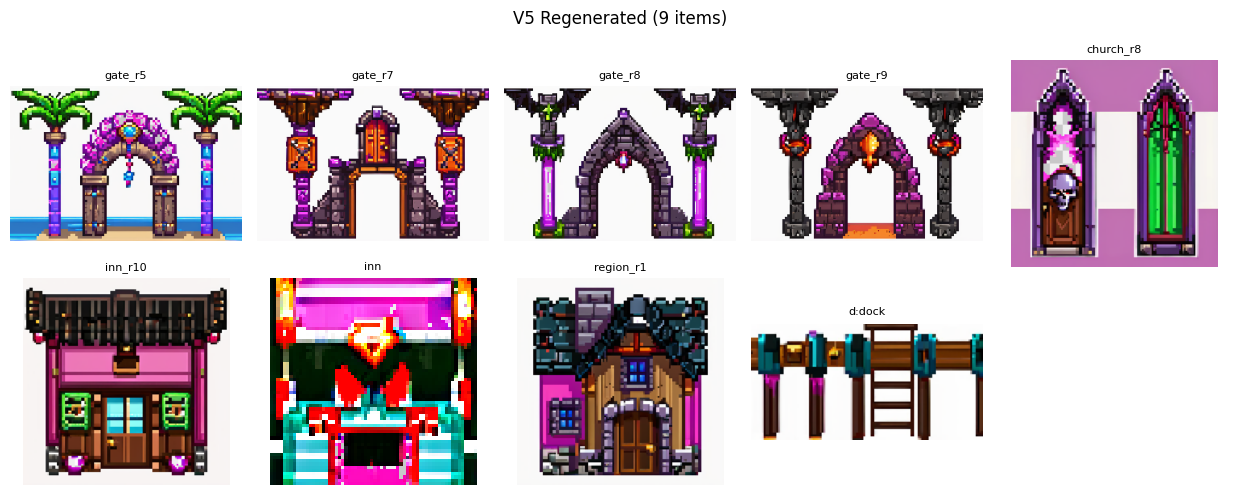

In [7]:
# Cell 6: Quality Scan + Preview
import matplotlib.pyplot as plt

print('=== V5 Quality Scan ===')
all_ok = True
for entry in V5_ENTRIES:
    out_dir = deco_dir if entry['type'] == 'deco' else bld_dir
    p = out_dir / f"{entry['name']}.png"
    if not p.exists():
        print(f'  MISSING: {entry["name"]}')
        all_ok = False
        continue
    img = Image.open(p).convert('RGBA')
    passed, opq = quality_check(img, entry['min_opaque'])
    kb = p.stat().st_size / 1024
    flag = 'v' if passed else 'X'
    print(f'  [{flag}] {entry["name"]:<22} opq={opq:>5.1%}  {kb:>5.0f}KB')
    if not passed:
        all_ok = False

if all_ok:
    print('\nAll V5 items pass quality check!')
else:
    print('\nSome items still failing — may need manual prompt tweaks.')

# Preview grid
pngs = [(deco_dir if e['type']=='deco' else bld_dir) / f"{e['name']}.png" for e in V5_ENTRIES]
pngs = [p for p in pngs if p.exists()]
if pngs:
    cols = min(5, len(pngs))
    rows = (len(pngs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
    axes = np.atleast_2d(axes)
    for ax in axes.flat: ax.axis('off')
    for i, p in enumerate(pngs):
        ax = axes[i//cols][i%cols]
        img = Image.open(p).convert('RGBA')
        w, h = img.size
        checker = np.zeros((h, w, 4), dtype=np.uint8)
        for y in range(h):
            for x in range(w):
                c = 200 if (x//8+y//8)%2==0 else 240
                checker[y, x] = [c, c, c, 255]
        bg = Image.fromarray(checker, 'RGBA')
        bg.paste(img, (0, 0), img)
        ax.imshow(bg)
        ax.set_title(p.stem.replace('bld_','').replace('deco_','d:'), fontsize=8)
    plt.suptitle(f'V5 Regenerated ({len(pngs)} items)', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('No images to preview.')

In [8]:
# Export + Download
import shutil

zip_path = '/content/buildings_v5_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'Zip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')


Zip: 0.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>